# Análisis Exploratorio y Clasificación Básica de Litologías con Datos Simulados de Registros de pozo.

** Autor: ** Juan Carlos Buri Loarte

## 1. Contexto del proyecto
 
En la industria de la geología petrolera, los registros de pozo (well logs) son una de las principales fuentes de información para caracterizar el subsuelo. Estos datos permiten inferir propiedades físicas de las rocas y diferenciar litologías, pero suelen ser voluminosos, ruidosos y requieren un análisis sistemático. Este proyecto se desarrolla en un entorno académico utilizando datos simulados, con el fin de replicar un escenario real de análisis geológico aplicando herramientas de ciencia de datos en Python.

## 2. Objetivo Principal

* Analizar, explorar y clasificar litologías básicas de arenas, lutitas y calizas a partir de datos simulados de registros de pozo, utilizando técnicas fundamentales de ciencia de datos como limpieza de datos, análisis exploratorio, visualización y reglas de clasificación simples, implementadas en Python dentro de Jupyter Notebook.

**2.1. Objetivos Secundarios**

* Manipulación y análisis de datos geológicos usando Pandas y NumPy.
* Aplicación de análisis exploratorio de datos (EDA) para identificar patrones entre registros de pozo.
* Uso de visualizaciones para interpretar relaciones geológicas.


## 3. Aporte real en la vida profesional y en la industria

Aunque el proyecto utiliza datos simulados, su aporte es directamente aplicable a la vida real porque:

* Replica el flujo de trabajo utilizado en proyectos reales de interpretación petrofísica y geológica.
* Demuestra cómo automatizar la identificación preliminar de litologías, reduciendo tiempo de interpretación manual.
* Sirve como base para futuros modelos de Machine Learning aplicados a datos reales de pozos.
* Integra conocimientos de geología con habilidades en análisis de datos, un perfil altamente demandado en la industria energética.

Este tipo de análisis es común en etapas de evaluación de yacimientos y toma de decisiones exploratorias.

## 4. Conceptos Básicos para el proyecto

Los datos de entrada que permitirán realizar el EDA son los siguientes: 

Gamma Ray (GR) mide la radiación gamma de las rocas, cumple con identificar lutitas (valores altos) y arenas o carbonatos (valores bajos), es clave para interpretar la litología; NPHI mide la cantidad de hidrógeno en la formación sobreestimada por agua ligada a minerales arcillosos y RHOB mide la densidad total de la formación, es decir distingue los tipos de roca estimando la porosidad, densidades bajas suelen indicar rocas más porosas o presencia de fluidos. Tiempo Sónico (DT) corresponde al tiempo que tarda una onda sonora en atravesar la formación, relacionando la velocidad sísmica con la porosidad y la compactación de la roca tomando en cuenta que valores altos suelen indicar mayor porosidad.

### Importación de librerías


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

np.random.seed (42)                                                      ## random, es un módulo controla la generación de números aleatorios en NumPy, .seed() inicializa el generador de números pseudoaleatorios con un valor específico etiqueta 42 . Generando los mismos números (0 al 1) cada vez que se ejecute.

### Generación del dataset simulado

In [11]:
# Profundidad
depth = np.arange(1000,1500,1)                                                          ### Función de NumPy que crea una secuencia de números siguiendo un patrón específico, inicia en 1000, termina en 1500 (no incluiye) + 1 a la vez.

# Simulación de litologías
lithology = np.random.choice(['Sandstome','Shale','Limestone'], size=len(depth))        ### Escoge rocas en base a depth cada vez que se ejecuta el código serán las mismas rocas.

# Listas
GR, RHOB, NPHI, DT = [],[],[],[]

for litho in lithology:
    if litho == 'Sandstone':
        GR.append(np.random.normal(60, 10))                                             ### Dame números aleatorios con función normal(decimales) que estén alrededor de 60 (media) con desviación estandar de 10 y agrega a la lista GR
        RHOB.append(np.random.normal(2.35, 0.05))
        NPHI.append(np.random.normal(0.25, 0.05))
        DT.append(np.random.normal(90, 5))
    elif litho == 'Shale':
        GR.append(np.random.normal(120, 15))
        RHOB.append(np.random.normal(2.55, 0.05))
        NPHI.append(np.random.normal(0.35, 0.05))
        DT.append(np.random.normal(110, 5))
    else: # Limestone
        GR.append(np.random.normal(40, 8))
        RHOB.append(np.random.normal(2.70, 0.04))
        NPHI.append(np.random.normal(0.10, 0.03))
        DT.append(np.random.normal(80, 4))

#DataFrame
well_data = pd.DataFrame({                                                               ### Crea un DataFrame de las siguientes columnas y sus respetivos valores (filas)
    'Depth_m': depth,
    'GR_API': GR,
    'RHOB_gcc': RHOB,
    'NPHI_frac': NPHI,
    'DT_usft': DT,
    'Lithology': lithology
})

well_data.head()

,Depth_m,GR_API,RHOB_gcc,NPHI_frac,DT_usft,Lithology
0,1000,35.280677,2.713242,0.075720,75.897106,Sandstome
1,1001,23.481078,2.748872,0.088007,80.628583,Limestone
2,1002,39.982095,2.657303,0.062228,75.978739,Limestone
3,1003,34.214652,2.714664,0.076128,86.985963,Limestone
4,1004,48.217208,2.732334,0.096410,86.057123,Sandstome


### Dataset guardado en CVS

In [15]:
well_data.to_csv('well_log_simulated', index= False)                          

### Exploración inicial de datos 

In [22]:
well_data.info()

well_data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Depth_m    500 non-null    int64  
 1   GR_API     500 non-null    float64
 2   RHOB_gcc   500 non-null    float64
 3   NPHI_frac  500 non-null    float64
 4   DT_usft    500 non-null    float64
 5   Lithology  500 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 23.6+ KB


,Depth_m,GR_API,RHOB_gcc,NPHI_frac,DT_usft,Lithology
count,500.000000,500.000000,500.000000,500.000000,500.000000,500
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Sandstome
freq,NaN,NaN,NaN,NaN,NaN,173
mean,1249.500000,64.992563,2.651649,0.176176,89.504999,NaN
std,144.481833,39.409443,0.080656,0.118969,14.534661,NaN
min,1000.000000,16.213551,2.411634,0.015943,67.069738,NaN
25%,1124.750000,36.499641,2.590089,0.088952,79.022640,NaN
50%,1249.500000,44.458085,2.675662,0.116867,82.153430,NaN
75%,1374.250000,107.291953,2.708996,0.309803,106.293901,NaN


### Limpieza de datos

In [80]:
# Revisión o busqueda de valores nulos

well_data.isna().sum()

# Reasigna el well_data con valores que cumplan las dos condicines.

well_data=well_data[(well_data['GR_API'] > 0) & (well_data['RHOB_gcc'] > 0)]                ### Selecciona valores >0 y desecha los valores negativos(-)

## Análisis exploratorio (EDA)

### Distribución de Gamma Ray

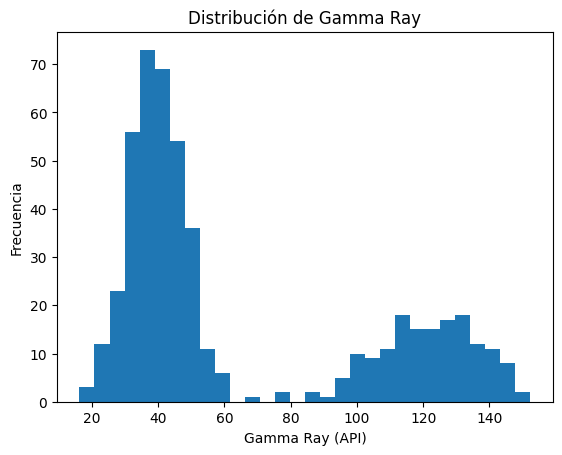

In [33]:
plt.figure()                                                       ### Crea una nueva figura vacía donde se va a dibujar el gráfico

plt.hist(well_data['GR_API'], bins=30)                             ### Crea el histograma: - Toma los datos de la columna 'GR_API' del DataFrame 'well_data' - bins=30 divide los datos en 30 intervalos (barras) para mostrar la distribución

plt.xlabel('Gamma Ray (API)')                                      ### Etiqueta del eje X
 
plt.ylabel('Frecuencia')                                           ### Etiqueta del eje y

plt.title('Distribución de Gamma Ray')                             ### Título del gráfico

plt.show()                                                         ### Muestra el gráfico en pantalla

- Se observa valores bajos de Gamma Ray 20-60 API muy limpias (areniscas limpias, areniscas cuarzosas, calizas puras) rocas con buena calidad de reservorio; en cuanto a la frecuencia los picos son muy altos indican que hay más muestras (más puntos de datos), es decir mayor concentración de ese tipo de roca en el pozo.
- El pico en GR 100-140 API representa menos cantidades de rocas con alto contenido de arcilla (lutitas o areniscas arcillosas).

### Cross-plot Relación RHOB vs NPHI

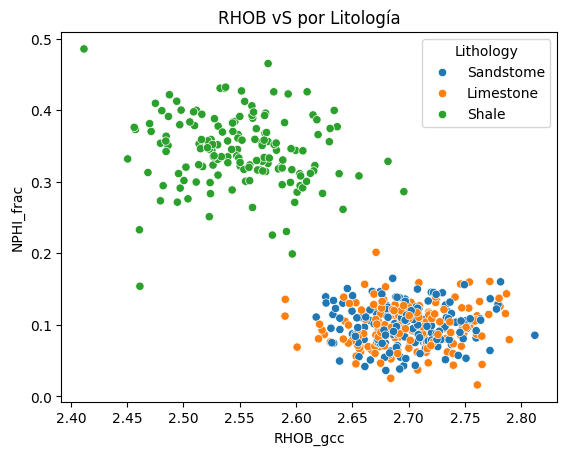

In [35]:
plt.figure()

sns.scatterplot(data=well_data, x='RHOB_gcc', y='NPHI_frac', hue='Lithology')                  ### Función de la librería Seaborn que crea gráficos de dispersión (scatter plots); usa tu DataFrame well_data como fuente de datos, selecciona valores (x,y); hue='Lithology': colorea los puntos según el tipo de roca


plt.title('RHOB vS por Litología')

plt.show()

El cross-plot NPHI vs RHOB indica una separación muy clara entre lutitas y areniscas-calizas. Los valores elevados de NPHI_frac asociados a bajas densidades corresponden a lutitas ricas en arcillas, donde la porosidad neutrón está sobreestimada debido al agua ligada. Esta observación justifica una corrección de NPHI mediante el volumen de arcilla (Vsh).

### Correción de porosidad 'NPHI'

Vsh es el volumen de arcilla de una formación y representa la fracción de minerales arcillosos presentes en las rocas. Se calcula a partir del registro Gamma Ray, normalizando sus valores entre arena limpia y lutita pura. El objetivo de la fórmula es cuantificar el contenido de arcilla de manera indirecta. Vsh permite corregir la porosidad, evaluar la calidad del reservorio y apoyar en la clasificación litológica. 

In [81]:
gr_describ = well_data['GR_API'].describe()                    ## Obtener valores min y max de la columna 'GR_API'

column_gr = 'GR_API'                                           ## Creo una nueva variable con la columna 'GR_API'

gr_min = well_data[column_gr].min()                            ## Se obtiene los valores min y max de la columna 'GR_API'

gr_max = well_data[column_gr].max()

Vsh = (well_data[column_gr] - gr_min) / (gr_max - gr_min)      ## Formula para corregir usando contenido de arcilla (Vsh) aplicando correción a la porosidad neutrón 

NPHI_corr = NPHI * (1 - Vsh)                                   ## Formula obtener el 'NPHI' corregido, eliminación del efecto de arcillas.                      

well_data['Vsh_new'] = Vsh                                     ## Se agregan nuevas columnas de 'Vsh' y 'NPHI_corr'

well_data['NPHI_corr'] = NPHI_corr

well_data.head(10)                                              ## Permite ver las 5 primeras filas del DataFrame

#print(type(NPHI_corr))                                        ## Para verificar si ya está calculada la variable NPHI_corr:

#print(NPHI_corr.shape)

#print(well_data.shape)                                        ## Para verificar las dimensiones del DataFrame:

#print(f"Filas en well_data: {well_data.shape[0]}")            ## Para comparar ambas dimensiones si coinciden con los numeros de filas:

#print(f"Elementos en NPHI_corr: {len(NPHI_corr)}")

#original = well_data['Lithology'].value_counts()               ## Cuántas muestras de cada tipo de litología tienes en tus datos originales

#predicha = well_data['Lithology_Predicted'].value_counts()     ## Muestra la distribución de las predicciones

#print("Original:")
#print(original)
#print("\nPredicha:")
#print(predicha)

,Depth_m,GR_API,RHOB_gcc,NPHI_frac,DT_usft,Lithology,Lithology_Predicted,Vsh_new,NPHI_corr
0,1000,35.280677,2.713242,0.075720,75.897106,Sandstome,Limestone,0.140064,0.065114
1,1001,23.481078,2.748872,0.088007,80.628583,Limestone,Limestone,0.053386,0.083309
2,1002,39.982095,2.657303,0.062228,75.978739,Limestone,Limestone,0.174600,0.051363
3,1003,34.214652,2.714664,0.076128,86.985963,Limestone,Limestone,0.132233,0.066062
4,1004,48.217208,2.732334,0.096410,86.057123,Sandstome,Limestone,0.235093,0.073745
5,1005,38.255955,2.698750,0.105099,82.807292,Sandstome,Limestone,0.161920,0.088082
6,1006,129.553621,2.526244,0.323350,113.199515,Shale,Shale,0.832577,0.054136
7,1007,45.721893,2.684266,0.052384,79.170736,Limestone,Limestone,0.216763,0.041029
8,1008,44.988206,2.772217,0.064061,78.293715,Sandstome,Limestone,0.211374,0.050520
9,1009,36.884772,2.754232,0.098952,76.370694,Limestone,Limestone,0.151847,0.083926


### Eliminación del efecto de arcillas


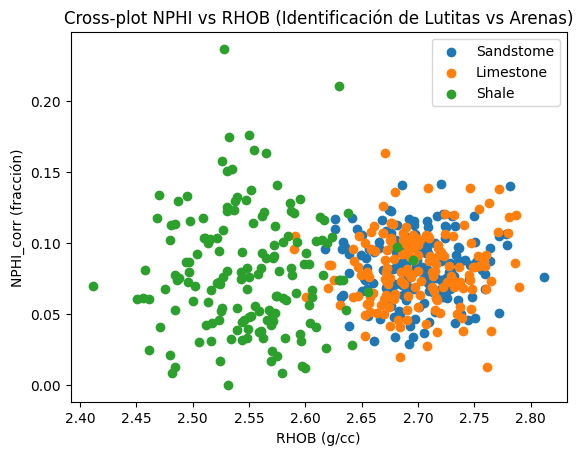

In [79]:
plt.figure()

for lith in well_data["Lithology"].unique():                                               ### Este bucle for itera sobre cada tipo de litología única en tus datos, es decir de todas las rxs de la columna 'Lithology' nos quedamos con las 3 (unicas): "Sandstone", "Shale", "Limestone".
   
    subset = well_data[well_data["Lithology"] == lith]                                     ### En cada iteración del bucle, esta línea crea un subconjunto de datos que contiene solo las filas, donde la litología coincide con la litología actual del bucle. Es como separar tus datos en grupos por tipo de roca
    
    plt.scatter(subset["RHOB_gcc"], subset["NPHI_corr"], label=lith)                       ### Crea un gráfico de dispersión para cada tipo de litología usando: x= densidad (RHOB_gcc); y= porosidad neutrón corregida (NPHI_corr); label= nombre de la litología (para la leyenda)

plt.xlabel("RHOB (g/cc)")

plt.ylabel("NPHI_corr (fracción)")

plt.title("Cross-plot NPHI vs RHOB (Identificación de Lutitas vs Arenas)")

plt.legend()                                                                               ### Muestra la leyenda de 'lith'

plt.show()

El cross-plot previo a la corrección emplea la porosidad neutrón original (NPHI_frac), por lo que la aplicación del volumen de arcilla (Vsh) no genera cambios visuales. La corrección se refleja únicamente cuando se grafica la porosidad neutrón corregida (NPHI_corr), donde los efectos del agua ligada en arcillas son eliminados.

### Comparación dos tablas

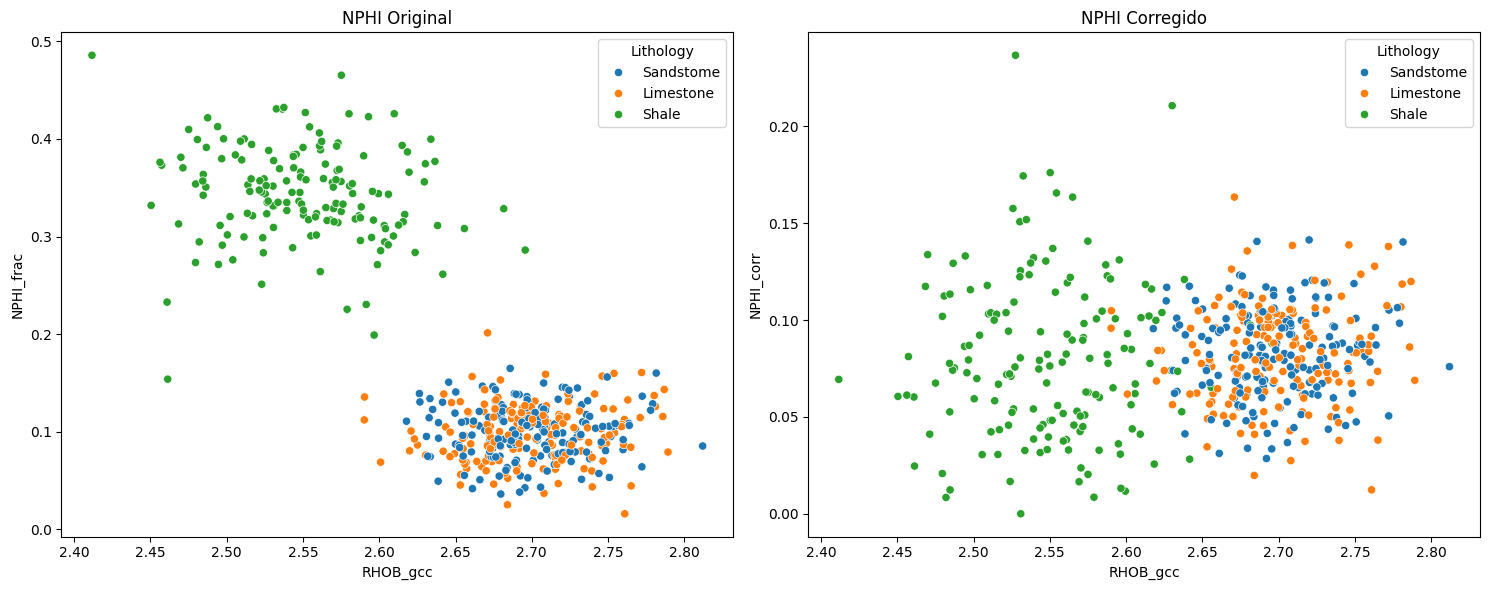

In [75]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))                                          ### Genera una figura (fig);ax1 left, ax2 right; .plt.subplots(función en matplotlib divide la hoja en 1 fila y 2 columnas,como dos cuadros lado a lado); figsize=(15, 6), tamaño de toda la hoja (15 de ancho, 6 de alto)

# Gráfico original
sns.scatterplot(data=well_data, x='RHOB_gcc', y='NPHI_frac', hue='Lithology', ax=ax1)         ### ax=ax1; dibuja este gráfico específicamente en el eje llamado ax1

ax1.set_title('NPHI Original')                                                                ### A ax1, ponle este 'título'

# Gráfico corregido  
sns.scatterplot(data=well_data, x='RHOB_gcc', y='NPHI_corr', hue='Lithology', ax=ax2)

ax2.set_title('NPHI Corregido')

plt.tight_layout()                                                                             ### Ajusta automáticamente el espaciado de los gráficos

plt.show()

Vista de las gráficos, reflejando el antes y despues de la corrección, ante los efectos del agua en arcillas.

### Clasificación básico por reglas (matriz de confusión) 

In [83]:
# Clasificación simple basada en reglas geológicas

def classify_lithology(GR):                                                             ### Crea una función 'classify_lithology', con los valores (GR)
    
    if GR < 50:                                                                         ### Cumple las siguientes funciones
        return 'Limestone'
    elif GR < 90:
        return 'Sandstone'
    else:
        return 'Shale'

well_data['Lithology_Predicted_1']=well_data['GR_API'].apply(classify_lithology)         ### Toma cada valor de la columna GR_API, pasa por la función 'classify_lithology' y crea una nueva columna Lithology_Predicted_1 con el resultado

pd.crosstab(well_data['Lithology'], well_data['Lithology_Predicted_1'])                  ### Crea una tabla de conteo que compara dos columnas y cuenta cuántas veces aparece cada combinación: Filas = Litología real (Lithology); Columnas= Litología predicha (Lithology_Predicted_1) Números: Cuántas veces coinciden o se equivocan

Lithology_Predicted_2,Limestone,Sandstone,Shale
Lithology,,,
Limestone,152,18,0
Sandstome,159,14,0
Shale,0,5,152


### Lectura por categorías:

Limestone (Caliza):
- De 170 muestras reales de caliza: 152 fueron correctamente identificadas, 18 se confundieron con arenisca, y 0 con lutita

Sandstone (Arenisca):
- De 173 muestras reales de arenisca: 14 fueron correctamente identificadas, 159 se confundieron con caliza, y 0 con lutita

Shale (Lutita):
- De 157 muestras reales de lutita: 152 fueron correctamente identificadas, 0 se confundió con caliza, y 5 con arenisca

### Confirmación del análisis:

Arenisca == Caliza (Confusión alta):
- Ambas tienen GR bajos (rangos superpuestos)
- Ambas son rocas no arcillosas (bajo contenido de minerales radiactivos)
- El modelo no puede distinguirlas efectivamente con solo GR

Lutita (Clasificación excelente):
- GR alto debido a minerales arcillosos (illita, montmorillonita)
- Rango claramente separado de las otras dos litologías
- Fácil identificación para el modelo

### Calcular métricas adicionales 

In [1]:
from sklearn.metrics import classification_report, precision_recall_fscore_support                                 ### Importación de librerías: Importa dos funciones de scikit-learn, calcula métricas de clasificación automática.

# Crear arrays con las predicciones basadas en tu matriz

y_true = (['Limestone']*170 + ['Sandstone']*173 + ['Shale']*157)                                                   ### Crea una lista con etiquetas verdaderas=170 elements 'Limestone'(muestras reales de calizas),173 'Sandstone'(m.r.areniscas),157 'Shale' (m.r lutita)
y_pred = (['Limestone']*152 + ['Sandstone']*18 + ['Limestone']*159 + 
          ['Sandstone']*14 + ['Shale']*152 + ['Sandstone']*5)                                                      ### Crea lista de predicciones del modelo basada en resultados matriz de confusión= 170 Limestone reales: 152 predichas como limestone + 18 Sandstone; 173 Sandstone reales: 159 predichas como Limestone + 14 como Sandstone; 157 Shale reales: 152 predichas como Shale + 5 como Sandstone

# Calcular métricas detalladas

print("Reporte de clasificación:")
print()
print(classification_report(y_true, y_pred))                                                                       ### Genera un reporte completo de precisión, recall. F1-score y soporte para cada clase

# Calcular métricas individuales

precisión, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)                     ### Calculo de métricas por separado para manipularlas individualmente; average=None calcula las metricas para cada clase por separado

print("\nMétricas por clase:")
print()
classes = ['Limestone', 'Sandstone', 'Shale']                                                                      ### Define los nombres de las clases para hacer la presentación más clara

for i, clase in enumerate(classes):                                                                                ### La función enumerate (classes) toma una lista y devuelve pares de(índice,valor), (índice) i=0.489 (valor)clase Limestone, i=0.378 clase Sandstone, i=1.00 clase Shale
    
    print(f'{clase}:')                                                                                             ### Imprime el nombre la clase
    print(f'  Precisión: {precisión[i]:.3f}')                                                                      ### Muestra las métricas usando el indice 'i' para acceder a los valores correspondientes en los arrays de precisión, recall y f1; Precisión mide que tan 'exacta o confiable' es la predicción cuando se dice que la rx es de cierto tipo
    print(f'  Recall (Sensibilidad): {recall[i]:.3f}')                                                             ### Recall: mide el % total real de cada tipo de rx se logra identificar correctamente 
    print(f'  F1-Score: {f1[i]:.3f}')


Reporte de clasificación:

              precision    recall  f1-score   support

   Limestone       0.49      0.89      0.63       170
   Sandstone       0.38      0.08      0.13       173
       Shale       1.00      0.97      0.98       157

    accuracy                           0.64       500
   macro avg       0.62      0.65      0.58       500
weighted avg       0.61      0.64      0.57       500


Métricas por clase:

Limestone:
  Precisión: 0.489
  Recall (Sensibilidad): 0.894
  F1-Score: 0.632
Sandstone:
  Precisión: 0.378
  Recall (Sensibilidad): 0.081
  F1-Score: 0.133
Shale:
  Precisión: 1.000
  Recall (Sensibilidad): 0.968
  F1-Score: 0.984


### Interpretación de las métricas:


Shale (Lutita) - Rendimiento excelente:
- Precisión 1.000: Cuando el modelo dice "es lutita", siempre acierta
- Recall 0.968: Identifica correctamente el 96.8% de las lutitas reales

Limestone (Caliza) - Rendimiento mixto:
- Precisión 0.489: Solo el 48.9% de las predicciones "caliza" son correctas
- Recall 0.894: Pero identifica el 89.4% de las calizas reales

Sandstone (Arenisca) - Rendimiento problemático:
- Precisión 0.378: Solo el 37.8% de las predicciones "arenisca" son correctas
- Recall 0.081: ¡Solo identifica el 8.1% de las areniscas reales!

### Conclusiones 


Los datos simulados muestran comportamientos coherentes con principios geológicos reales.
- El Gamma Ray es una variable clave para la diferenciación de litologías.
- En lutitas, el registro de porosidad neutrón NPHI presenta valores elevados (gráfico cross-plot) debido a la presencia de minerales arcillosos que contienen agua ligada en su estructura cristalina y no porque haya buena porosidad efectiva. Este hidrógeno es detectado por la herramienta neutrón y se interpreta erróneamente como porosidad, generando una sobreestimación de la porosidad efectiva.
- La porosidad neutrón original ('NPHI_frac') fue corregida utilizando el volumen de arcilla (Vsh) derivado del registro Gamma Ray ('GR_API'), eliminando el efecto del agua ligada en minerales arcillosos. Esta corrección permitió mejorar la separación entre litologías y optimizar el desempeño del modelo de clasificación.
- La superposición de rangos de GR bajos y la naturaleza no arcillosa de las rocas Limestone y Sandstone explica una fuerte confusión entre estas dos rocas (caliza y arenisca); mientras que la roca Shale (lutita) se clasifica bien porque su GR es alto y la separa claramente de las otras dos rocas.
